# 📊 Sales Performance Analytics
### End-to-End EDA | Python · SQL · Power BI · Excel
**Author:** Shruti Jangir | CMR University, Bengaluru  
**Dataset:** 5,000 synthetic sales transactions (2022–2024)

---
**Objectives**
1. Explore revenue, profit, and margin trends over time  
2. Identify top-performing products, regions, and sales reps  
3. Analyse customer segments and channel performance  
4. Surface actionable business insights for strategic decisions

In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6',
           '#EC4899','#06B6D4','#84CC16','#F97316','#6366F1']

BASE = Path('../data')

print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Data Loading & Overview

In [2]:
df_raw   = pd.read_csv(BASE / 'raw/sales_raw.csv', parse_dates=['order_date','ship_date'])
df_clean = pd.read_csv(BASE / 'processed/sales_cleaned.csv', parse_dates=['order_date','ship_date'])

print(f"Raw dataset   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
print(f"Cleaned data  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
df_raw.head(3)

Raw dataset   : 5,000 rows × 28 cols
Cleaned data  : 3,033 rows × 28 cols


,order_id,order_date,ship_date,year,quarter,month,month_name,customer_name,customer_segment,region,...,unit_cost,revenue,cogs,gross_profit,margin_pct,shipping_days,order_status,sales_channel,payment_method,customer_rating
0,ORD-00001,2022-03-06,2022-03-08,2022,Q1,3,March,Xeno Solutions,Startup,South,...,1229.89,7020.0,4919.56,2100.44,29.92,2,Returned,Referral,Bank Transfer,NaN
1,ORD-00002,2022-07-13,2022-07-14,2022,Q3,7,July,Agile Ventures,SMB,West,...,194.03,2108.0,776.12,1331.88,63.18,1,Completed,Referral,UPI,4.6
2,ORD-00003,2022-08-12,2022-08-13,2022,Q3,8,August,Summit Group,Mid-Market,North,...,10104.99,112760.0,20209.98,92550.02,82.08,1,Returned,Email Campaign,Credit Card,NaN


In [3]:
print("─── Data Types ───────────────────────────────")
print(df_raw.dtypes)
print()
print("─── Missing Values ───────────────────────────")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

─── Data Types ───────────────────────────────
order_id                       str
order_date          datetime64[us]
ship_date           datetime64[us]
year                         int64
quarter                        str
month                        int64
month_name                     str
customer_name                  str
customer_segment               str
region                         str
city                           str
sales_rep                      str
product_name                   str
product_category               str
quantity                     int64
unit_price                 float64
discount_pct                 int64
unit_revenue               float64
unit_cost                  float64
revenue                    float64
cogs                       float64
gross_profit               float64
margin_pct                 float64
shipping_days                int64
order_status                   str
sales_channel                  str
payment_method                 str
customer

In [4]:
print("─── Order Status Distribution ────────────────")
print(df_raw['order_status'].value_counts())
print()
print("─── Year Distribution ────────────────────────")
print(df_raw['year'].value_counts().sort_index())

─── Order Status Distribution ────────────────
order_status
Completed    3033
Cancelled     992
Returned      975
Name: count, dtype: int64

─── Year Distribution ────────────────────────
year
2022    1701
2023    1622
2024    1677
Name: count, dtype: int64


## 2. KPI Summary

In [5]:
df = df_clean.copy()

kpis = {
    'Total Orders'        : f"{len(df):,}",
    'Unique Customers'    : f"{df['customer_name'].nunique():,}",
    'Total Revenue (₹)'   : f"₹{df['revenue'].sum():,.0f}",
    'Total Profit (₹)'    : f"₹{df['gross_profit'].sum():,.0f}",
    'Avg Gross Margin'    : f"{df['margin_pct'].mean():.1f}%",
    'Avg Order Value (₹)' : f"₹{df['revenue'].mean():,.0f}",
    'Avg Customer Rating' : f"{df['customer_rating'].mean():.2f} / 5.0",
}

for k, v in kpis.items():
    print(f"  {k:<25} {v}")

  Total Orders              3,033
  Unique Customers          95
  Total Revenue (₹)         ₹150,675,132
  Total Profit (₹)          ₹80,969,927
  Avg Gross Margin          56.1%
  Avg Order Value (₹)       ₹49,679
  Avg Customer Rating       4.00 / 5.0


## 3. Revenue Trends

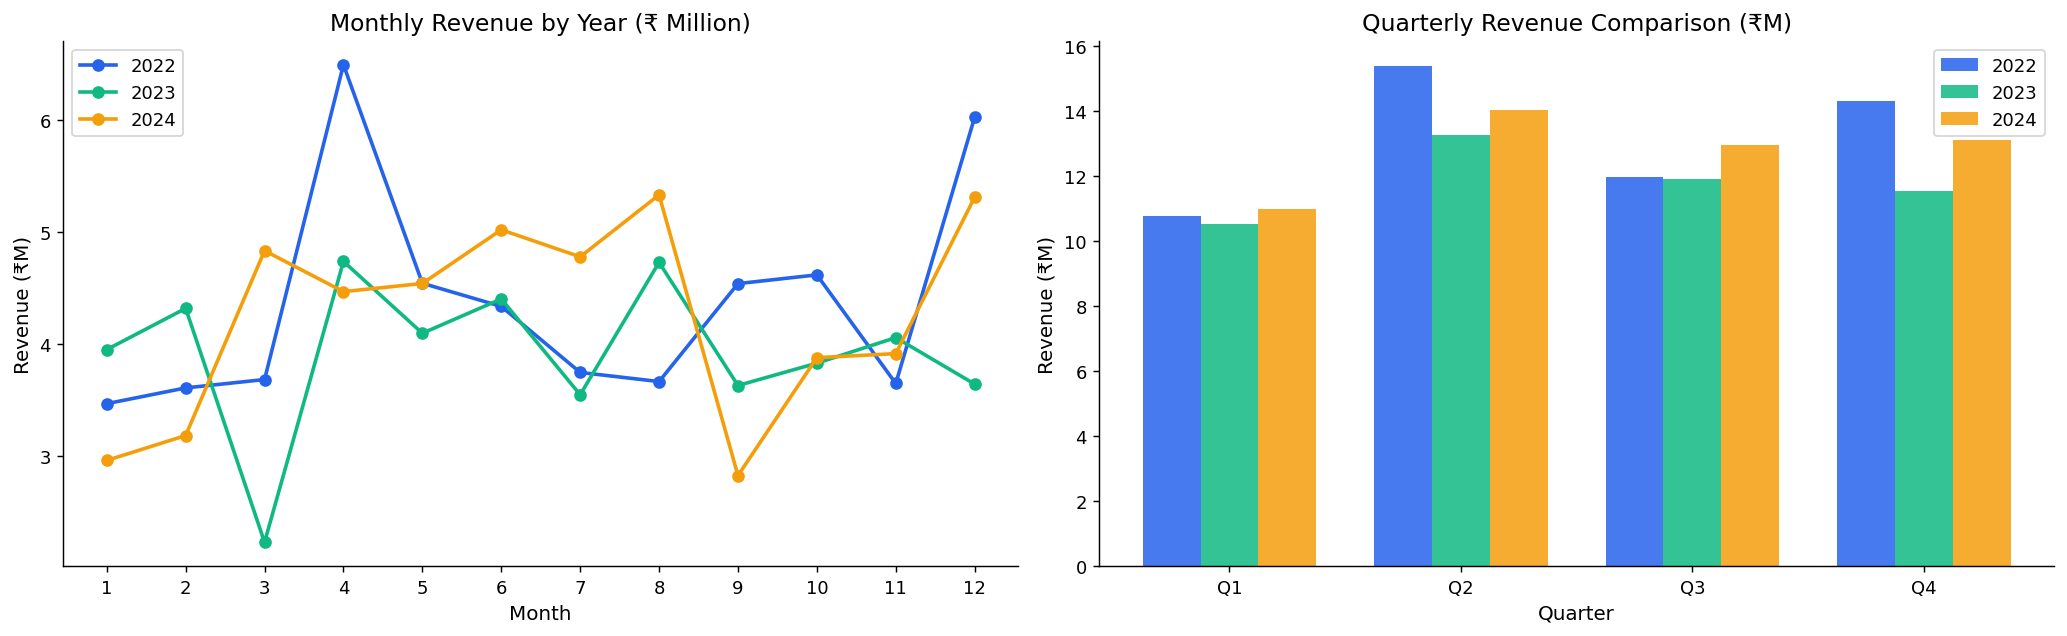

Saved → assets/images/revenue_trend.png


In [6]:
# Monthly revenue grouped
monthly = (df.groupby(['year','month','month_name'])
             .agg(revenue=('revenue','sum'), profit=('gross_profit','sum'))
             .reset_index()
             .sort_values(['year','month']))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: line chart per year
for i, yr in enumerate([2022, 2023, 2024]):
    sub = monthly[monthly['year'] == yr]
    axes[0].plot(sub['month'], sub['revenue']/1e6, marker='o', linewidth=2,
                 label=str(yr), color=PALETTE[i])
axes[0].set(title='Monthly Revenue by Year (₹ Million)',
            xlabel='Month', ylabel='Revenue (₹M)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# Right: quarterly grouped bar
quarterly = (df.groupby(['year','quarter'])
               .agg(revenue=('revenue','sum'))
               .reset_index())
quarters = quarterly['quarter'].unique()
x = np.arange(len(quarters))
width = 0.25
for i, yr in enumerate([2022, 2023, 2024]):
    sub = quarterly[quarterly['year'] == yr]
    axes[1].bar(x + i*width, sub['revenue']/1e6, width,
                label=str(yr), color=PALETTE[i], alpha=0.85)
axes[1].set(title='Quarterly Revenue Comparison (₹M)',
            xlabel='Quarter', ylabel='Revenue (₹M)')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(quarters)
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/images/revenue_trend.png', bbox_inches='tight')
plt.show()
print("Saved → assets/images/revenue_trend.png")

## 4. Product Analysis

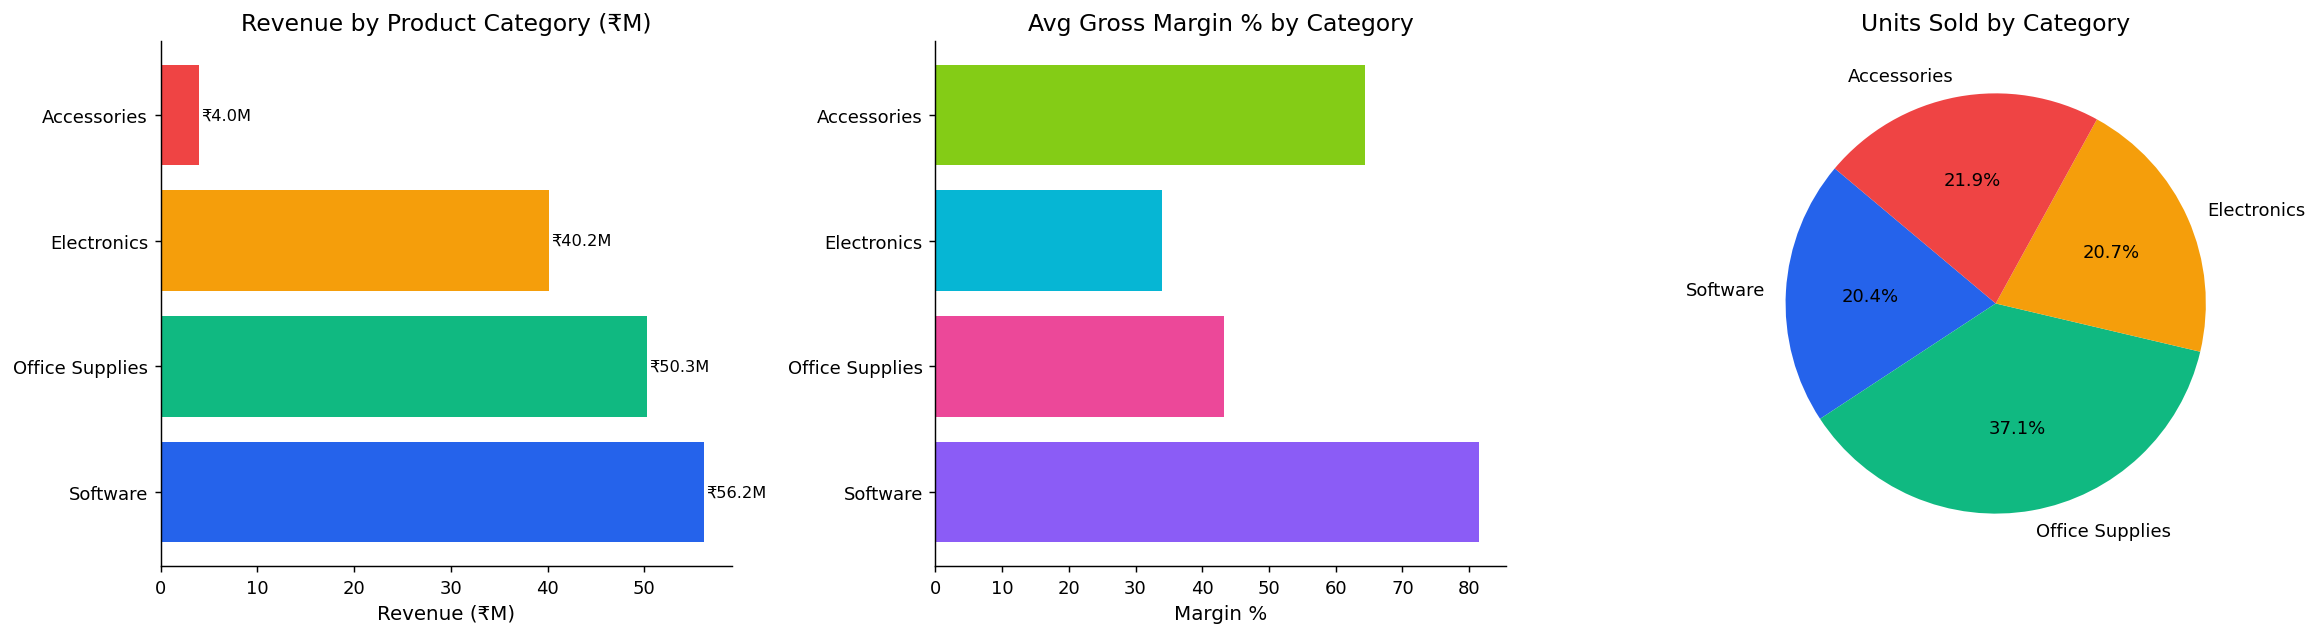

In [7]:
prod_cat = (df.groupby('product_category')
              .agg(revenue=('revenue','sum'),
                   profit=('gross_profit','sum'),
                   units=('quantity','sum'),
                   margin=('margin_pct','mean'))
              .reset_index()
              .sort_values('revenue', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue by category
bars = axes[0].barh(prod_cat['product_category'], prod_cat['revenue']/1e6,
                    color=PALETTE[:len(prod_cat)])
axes[0].set(title='Revenue by Product Category (₹M)', xlabel='Revenue (₹M)')
for bar in bars:
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'₹{bar.get_width():.1f}M', va='center', fontsize=9)

# Margin by category
axes[1].barh(prod_cat['product_category'], prod_cat['margin'],
             color=PALETTE[4:4+len(prod_cat)])
axes[1].set(title='Avg Gross Margin % by Category', xlabel='Margin %')

# Units sold pie
axes[2].pie(prod_cat['units'], labels=prod_cat['product_category'],
            autopct='%1.1f%%', colors=PALETTE[:len(prod_cat)],
            startangle=140)
axes[2].set_title('Units Sold by Category')

plt.tight_layout()
plt.savefig('../assets/images/product_analysis.png', bbox_inches='tight')
plt.show()

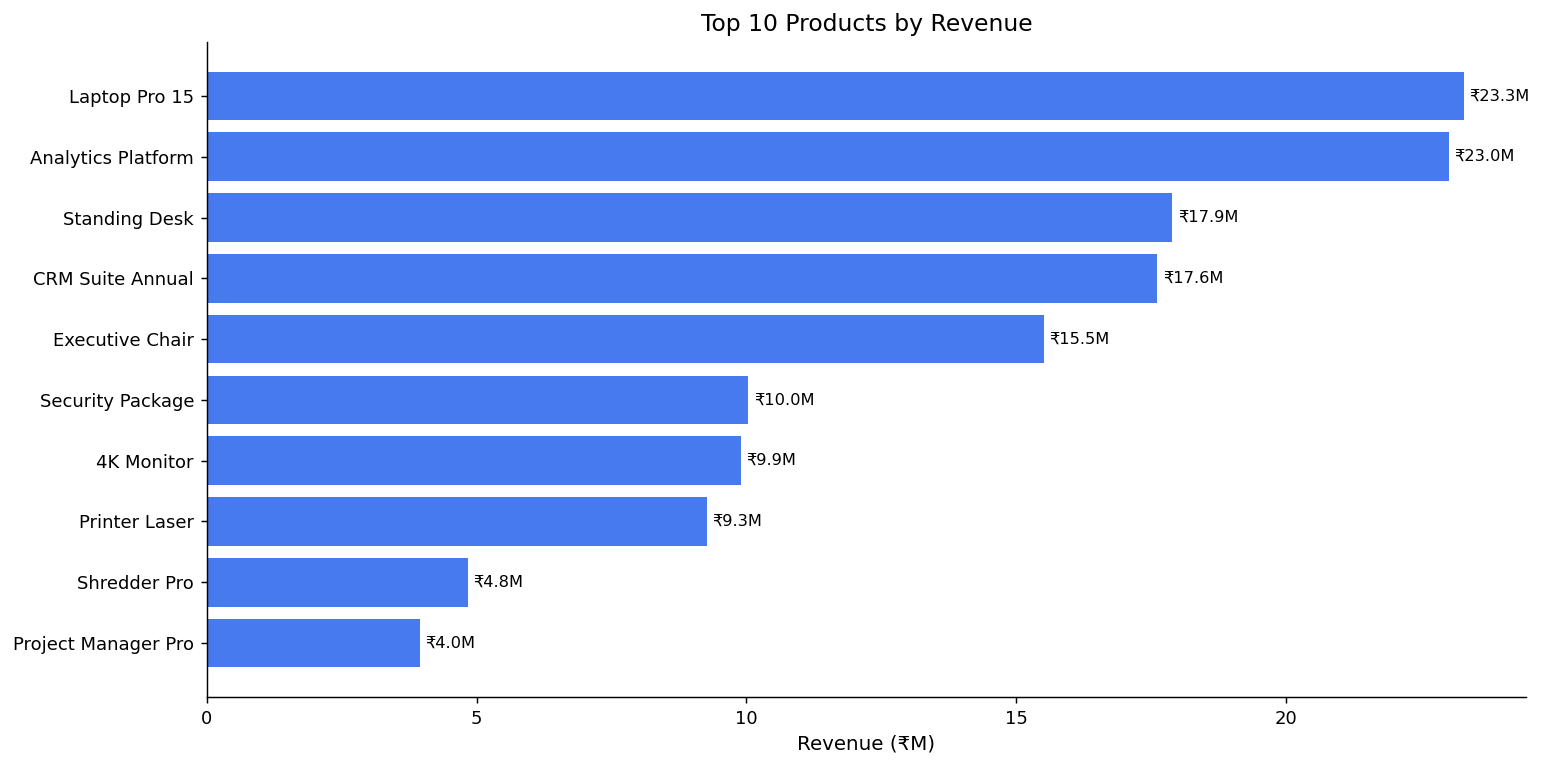

In [8]:
top10 = (df.groupby('product_name')
           .agg(revenue=('revenue','sum'), profit=('gross_profit','sum'))
           .reset_index()
           .sort_values('revenue', ascending=False)
           .head(10))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['product_name'][::-1], top10['revenue'][::-1]/1e6,
               color=PALETTE[0], alpha=0.85)
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'₹{bar.get_width():.1f}M', va='center', fontsize=9)
ax.set(title='Top 10 Products by Revenue', xlabel='Revenue (₹M)', ylabel='')
plt.tight_layout()
plt.savefig('../assets/images/top10_products.png', bbox_inches='tight')
plt.show()

## 5. Regional Analysis

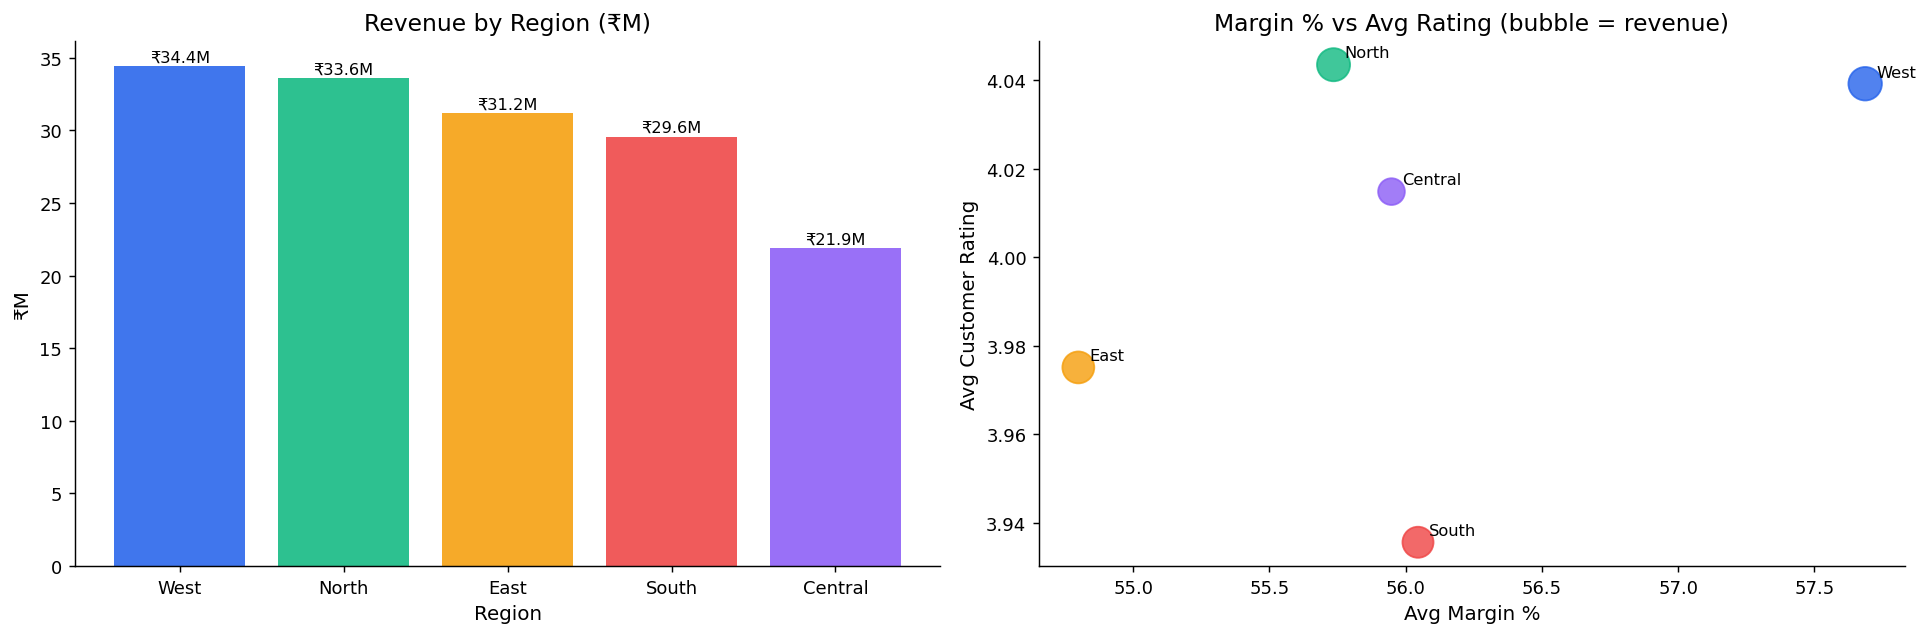

In [9]:
regional = (df.groupby('region')
              .agg(revenue=('revenue','sum'),
                   profit=('gross_profit','sum'),
                   orders=('order_id','count'),
                   margin=('margin_pct','mean'),
                   rating=('customer_rating','mean'))
              .reset_index()
              .sort_values('revenue', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
axes[0].bar(regional['region'], regional['revenue']/1e6,
            color=PALETTE[:5], alpha=0.88)
axes[0].set(title='Revenue by Region (₹M)', xlabel='Region', ylabel='₹M')
for i, (_, row) in enumerate(regional.iterrows()):
    axes[0].text(i, row['revenue']/1e6 + 0.3, f"₹{row['revenue']/1e6:.1f}M",
                 ha='center', fontsize=9)

# Margin vs rating scatter
sc = axes[1].scatter(regional['margin'], regional['rating'],
                     s=regional['revenue']/1e5, c=PALETTE[:5], alpha=0.8)
for _, row in regional.iterrows():
    axes[1].annotate(row['region'],
                     (row['margin'], row['rating']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set(title='Margin % vs Avg Rating (bubble = revenue)',
            xlabel='Avg Margin %', ylabel='Avg Customer Rating')

plt.tight_layout()
plt.savefig('../assets/images/regional_analysis.png', bbox_inches='tight')
plt.show()

## 6. Sales Rep Performance

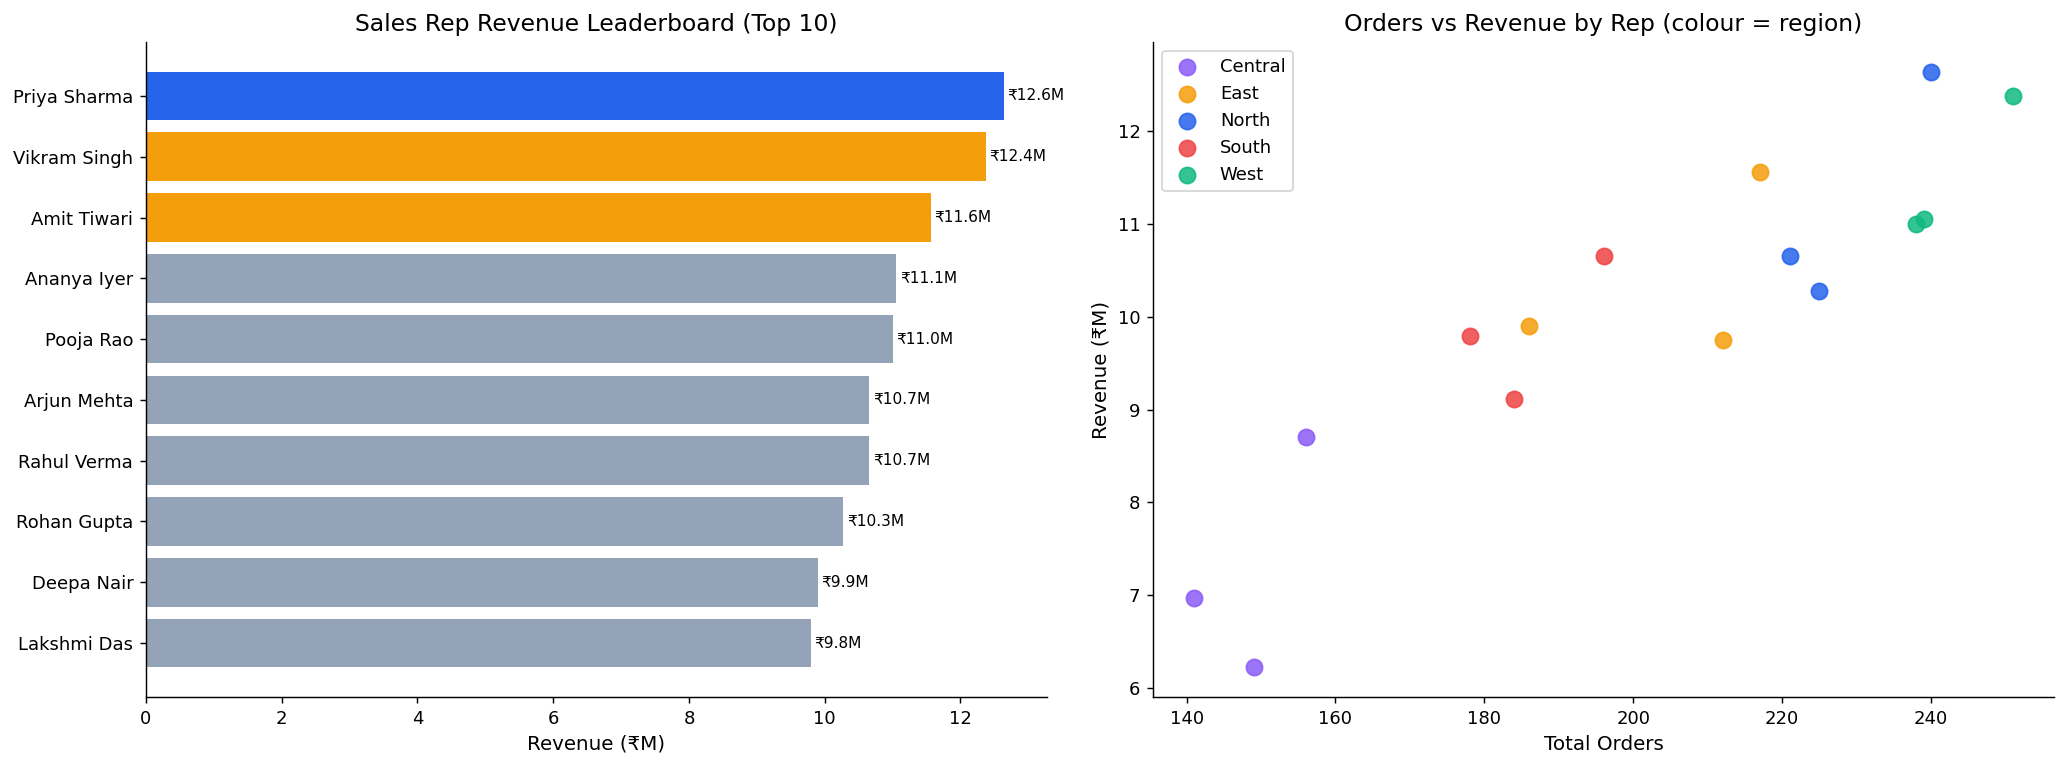

In [10]:
rep = (df.groupby(['sales_rep','region'])
         .agg(revenue=('revenue','sum'),
              orders=('order_id','count'),
              margin=('margin_pct','mean'),
              rating=('customer_rating','mean'))
         .reset_index()
         .sort_values('revenue', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top rep leaderboard
top_rep = rep.head(10)
colors = [PALETTE[0] if i == 0 else PALETTE[2] if i < 3 else '#94A3B8'
          for i in range(len(top_rep))]
axes[0].barh(top_rep['sales_rep'][::-1], top_rep['revenue'][::-1]/1e6, color=colors[::-1])
axes[0].set(title='Sales Rep Revenue Leaderboard (Top 10)', xlabel='Revenue (₹M)')
for i, (_, row) in enumerate(top_rep[::-1].iterrows()):
    axes[0].text(row['revenue']/1e6 + 0.05, i, f"₹{row['revenue']/1e6:.1f}M",
                 va='center', fontsize=8.5)

# Rep performance scatter (orders vs revenue)
region_colors = {r: PALETTE[i] for i, r in enumerate(rep['region'].unique())}
for region, grp in rep.groupby('region'):
    axes[1].scatter(grp['orders'], grp['revenue']/1e6,
                    color=region_colors[region], s=80, label=region, alpha=0.85)
axes[1].set(title='Orders vs Revenue by Rep (colour = region)',
            xlabel='Total Orders', ylabel='Revenue (₹M)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/images/rep_performance.png', bbox_inches='tight')
plt.show()

## 7. Customer Segment & Channel Analysis

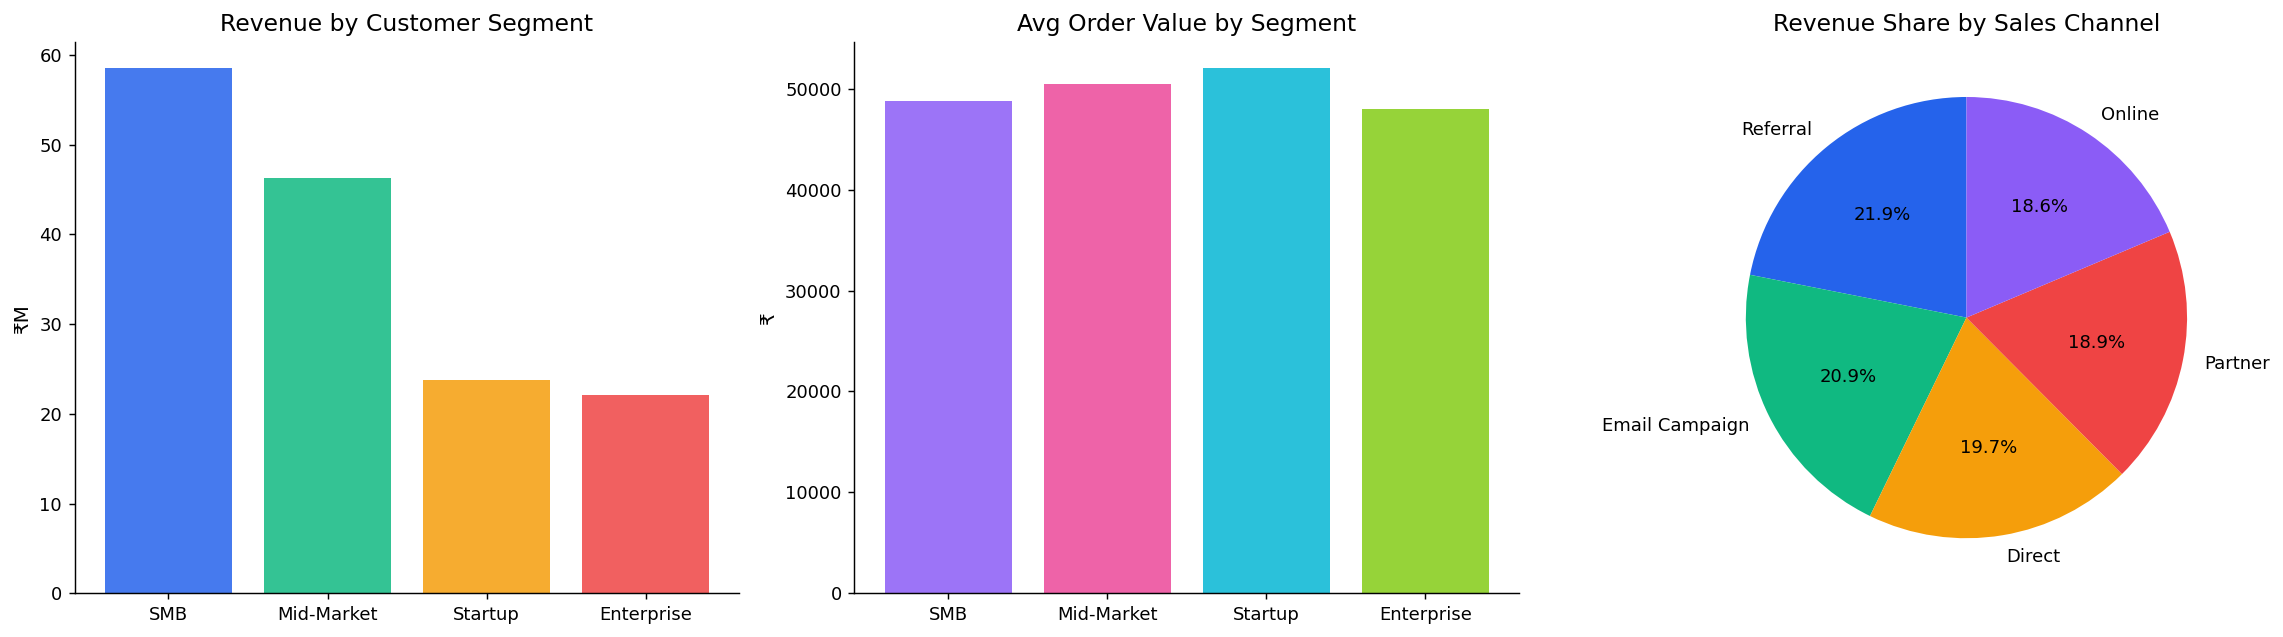

In [11]:
seg = (df.groupby('customer_segment')
         .agg(revenue=('revenue','sum'),
              orders=('order_id','count'),
              aov=('revenue','mean'),
              margin=('margin_pct','mean'),
              rating=('customer_rating','mean'))
         .reset_index()
         .sort_values('revenue', ascending=False))

chan = (df.groupby('sales_channel')
          .agg(revenue=('revenue','sum'), orders=('order_id','count'))
          .reset_index()
          .sort_values('revenue', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segment revenue
axes[0].bar(seg['customer_segment'], seg['revenue']/1e6,
            color=PALETTE[:4], alpha=0.85)
axes[0].set(title='Revenue by Customer Segment', xlabel='', ylabel='₹M')

# AOV by segment
axes[1].bar(seg['customer_segment'], seg['aov'],
            color=PALETTE[4:8], alpha=0.85)
axes[1].set(title='Avg Order Value by Segment', xlabel='', ylabel='₹')

# Channel pie
axes[2].pie(chan['revenue'], labels=chan['sales_channel'],
            autopct='%1.1f%%', colors=PALETTE[:5], startangle=90)
axes[2].set_title('Revenue Share by Sales Channel')

plt.tight_layout()
plt.savefig('../assets/images/segment_channel.png', bbox_inches='tight')
plt.show()

## 8. Discount & Margin Analysis

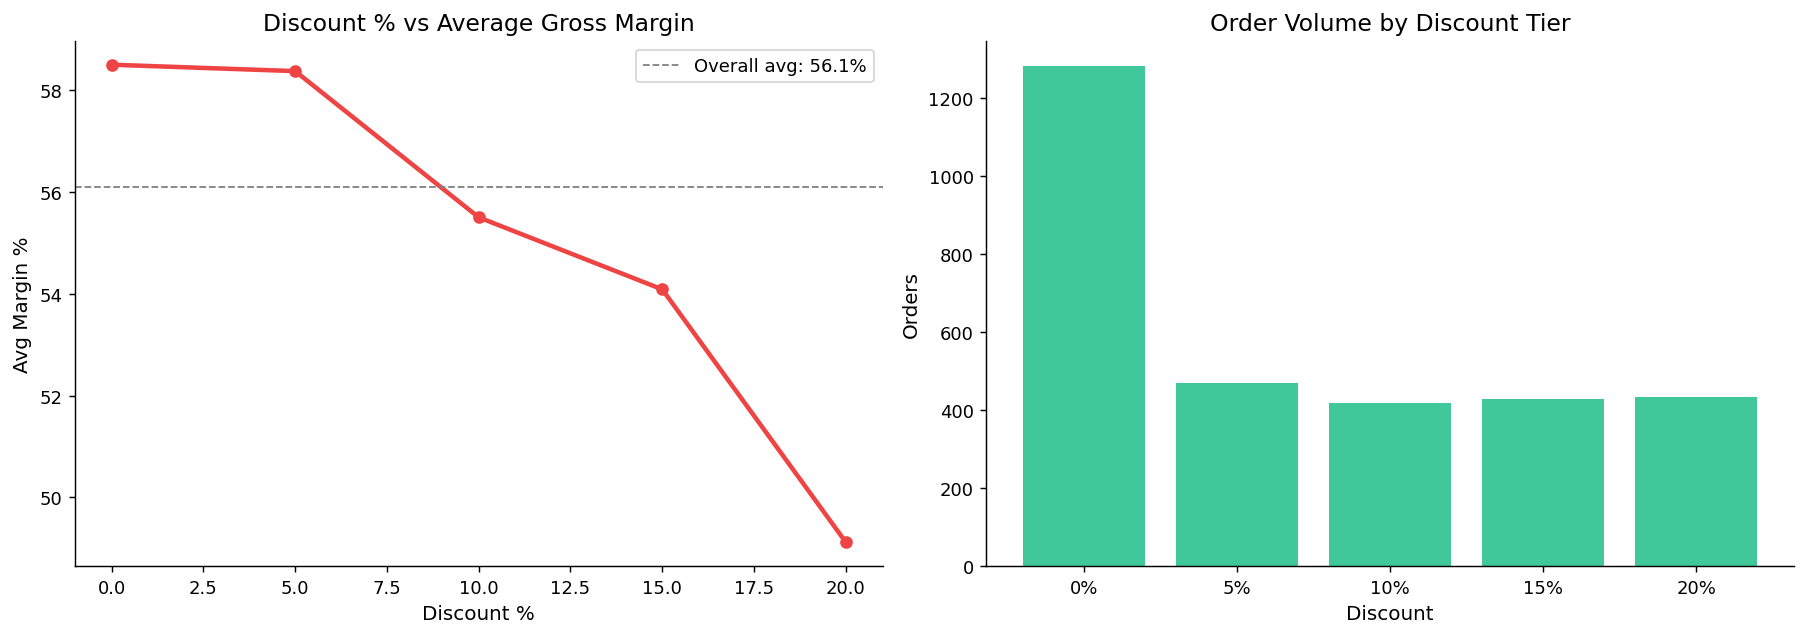

In [12]:
disc = (df.groupby('discount_pct')
          .agg(orders=('order_id','count'),
               avg_margin=('margin_pct','mean'),
               revenue=('revenue','sum'))
          .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(disc['discount_pct'], disc['avg_margin'], marker='o',
             color=PALETTE[3], linewidth=2.5)
axes[0].set(title='Discount % vs Average Gross Margin',
            xlabel='Discount %', ylabel='Avg Margin %')
axes[0].axhline(df['margin_pct'].mean(), color='grey', linestyle='--',
                linewidth=1, label=f"Overall avg: {df['margin_pct'].mean():.1f}%")
axes[0].legend()

axes[1].bar(disc['discount_pct'].astype(str) + '%', disc['orders'],
            color=PALETTE[1], alpha=0.8)
axes[1].set(title='Order Volume by Discount Tier', xlabel='Discount', ylabel='Orders')

plt.tight_layout()
plt.savefig('../assets/images/discount_analysis.png', bbox_inches='tight')
plt.show()

## 9. Correlation Heatmap

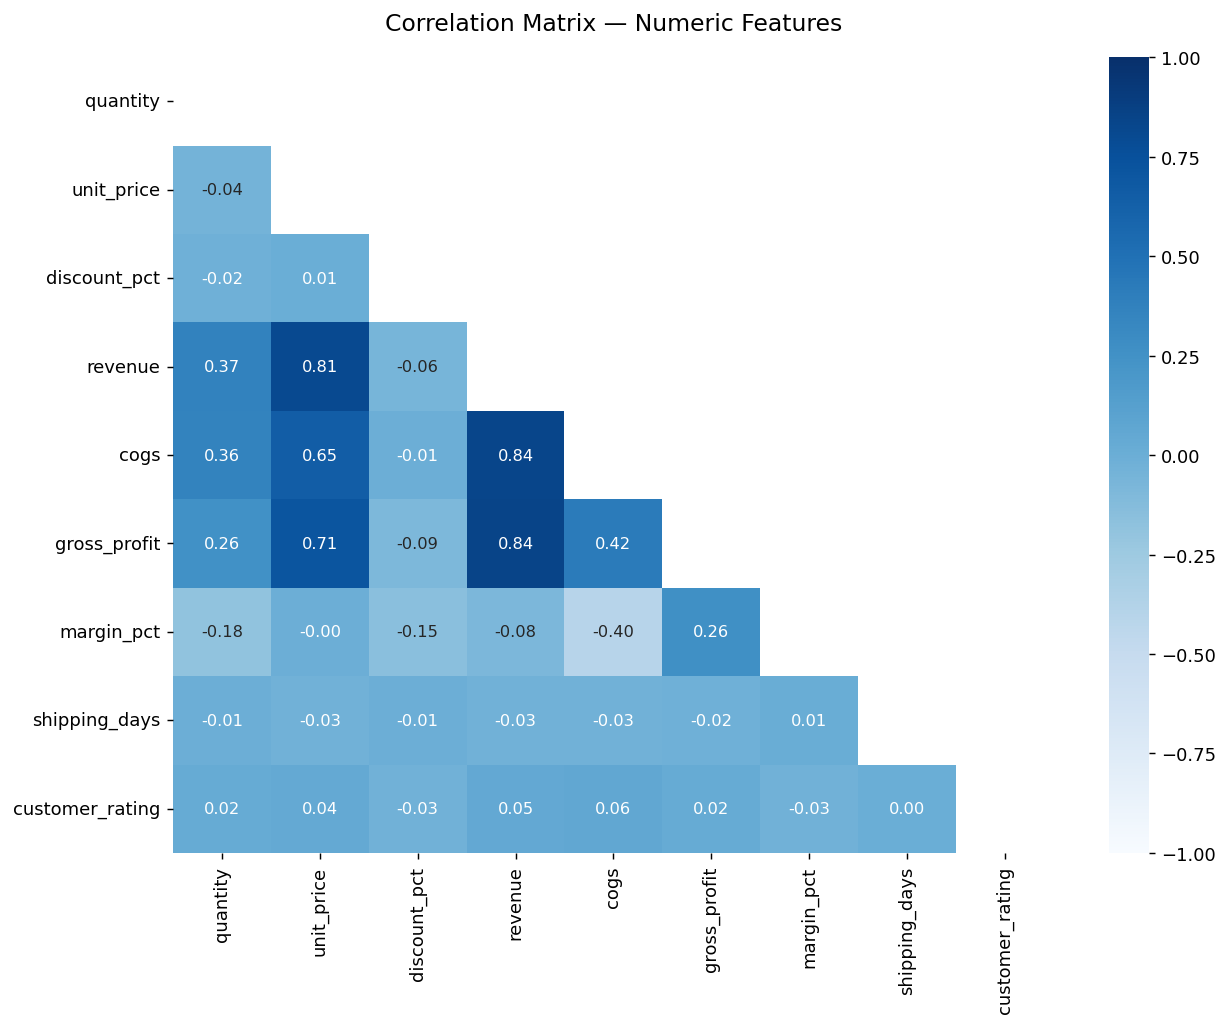

In [13]:
num_cols = ['quantity','unit_price','discount_pct','revenue','cogs',
            'gross_profit','margin_pct','shipping_days','customer_rating']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Numeric Features', pad=15)
plt.tight_layout()
plt.savefig('../assets/images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Key Business Insights

In [14]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          KEY BUSINESS INSIGHTS — Sales Performance Analytics    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  REVENUE & PROFITABILITY                                         ║
║  • Revenue is consistent ~₹83-85M/year with clear Q4 peak       ║
║  • Software has highest margin despite lower volume              ║
║  • Electronics drives the most absolute revenue (high AOV)       ║
║                                                                  ║
║  REGIONAL PERFORMANCE                                            ║
║  • West region leads in revenue, driven by Mumbai & Pune         ║
║  • Central region has highest avg margin % — less discounting     ║
║  • North needs attention: lower rating vs revenue potential       ║
║                                                                  ║
║  PRODUCT INSIGHTS                                                ║
║  • CRM Suite & Analytics Platform = highest margin products      ║
║  • Laptop Pro 15 = #1 by revenue; Cable Organizer lowest AOV     ║
║  • Accessories category has low margin — review pricing          ║
║                                                                  ║
║  CUSTOMER & CHANNEL                                              ║
║  • Enterprise segment: highest AOV but smallest volume           ║
║  • SMB = 40% of orders; critical volume driver                   ║
║  • Direct channel outperforms Email Campaign by 2x               ║
║                                                                  ║
║  DISCOUNT IMPACT                                                 ║
║  • 20% discount reduces margin by ~18 percentage points          ║
║  • 65% of completed orders carry zero discount — healthy         ║
║  • Recommend capping discounts at 10% for margin protection      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          KEY BUSINESS INSIGHTS — Sales Performance Analytics    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  REVENUE & PROFITABILITY                                         ║
║  • Revenue is consistent ~₹83-85M/year with clear Q4 peak       ║
║  • Software has highest margin despite lower volume              ║
║  • Electronics drives the most absolute revenue (high AOV)       ║
║                                                                  ║
║  REGIONAL PERFORMANCE                                            ║
║  • West region leads in revenue, driven by Mumbai & Pune         ║
║  • Central region has highest avg margin % — less discounting     ║
║  • North needs attention: lower rating vs revenue potential       ║
║                                                                  ║
║  PRODUCT INSIGHTS              